# Ddri 환경 Feature 설명 노트북

이 노트북은 군집 결과를 공간 환경 정보와 연결해 해석하는 문서다.

## 이 노트북의 목적

- 공원, 지하철, 버스 접근성 feature가 어떻게 만들어졌는지 설명한다.
- 군집별 환경 차이를 표와 차트로 확인한다.
- 현재 가능한 해석과 아직 보류해야 하는 해석을 구분한다.

## 1. 기본 경로 설정

환경 해석은 원본 위치 데이터와 군집 결과를 결합해 만든다. 최종 산출물은 환경 feature 원본, 군집별 환경 요약, 대표 대여소 표, 비교 차트 형태로 저장한다.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

BASE_DIR = Path('/Users/cheng80/Desktop/ddri_work')
DATA_DIR = BASE_DIR / 'works' / '01_clustering' / '03_environment' / 'data'
IMG_DIR = BASE_DIR / 'works' / '01_clustering' / '03_environment' / 'images'

feature_path = DATA_DIR / 'ddri_cluster_environment_features.csv'
summary_path = DATA_DIR / 'ddri_cluster_environment_summary.csv'
rep_path = DATA_DIR / 'ddri_cluster_representative_stations.csv'

## 2. 군집별 환경 요약 확인

여기서 보는 값은 군집 평균이다. 지하철 거리와 버스 접근성이 고수요형에서 어떻게 달라지는지 먼저 확인하는 것이 핵심이다.

In [2]:
summary_df = pd.read_csv(summary_path)
display(summary_df)

,cluster,cluster_name,park_distance_m,subway_distance_m,bus_stop_count_300m,bus_stop_count_500m,avg_rental
0,0,일반수요형,1036.82,551.64,26.98,60.48,11.91
1,1,고수요형,1170.43,387.75,32.56,68.09,31.18


## 3. 대표 대여소 확인

군집 해석은 평균값만 보면 추상적으로 느껴질 수 있다. 그래서 각 군집에서 평균 대여량이 높은 대표 대여소를 함께 보는 것이 발표 설명에 도움이 된다.

In [3]:
rep_df = pd.read_csv(rep_path)
display(rep_df.head(10))

,station_id,avg_rental,rental_std,weekday_avg,weekend_avg,peak_ratio,night_ratio,weekday_weekend_gap,cluster,pca_1,...,주소,station_lat,station_lon,park_distance_m,nearest_park_name,subway_distance_m,nearest_subway_name,bus_stop_count_300m,bus_stop_count_500m,cluster_name
0,2308,21.877915,9.994926,22.692898,19.836538,0.320083,0.121951,2.856360,0,0.925599,...,서울특별시 강남구 압구정로 311,37.529301,127.035599,516.774113,도산근린공원,484.737255,압구정로데오,20,56,일반수요형
1,4914,21.546703,11.140371,24.130518,15.043478,0.309065,0.079051,9.087040,0,1.244237,...,삼성동 159-9,37.509991,127.058472,508.029365,봉은공원,432.747544,삼성(무역센터),28,132,일반수요형
2,2324,20.709589,9.378962,20.908046,20.211538,0.341447,0.131036,0.696508,0,0.634741,...,서울특별시 강남구 도곡로 540,37.500439,127.066223,1771.069315,봉은공원,570.038639,학여울,32,48,일반수요형
3,4923,20.486676,9.486546,21.212181,18.676471,0.373451,0.119806,2.535710,0,0.740561,...,서울특별시 강남구 영동대로 214-2,37.498615,127.068314,2041.540219,봉은공원,295.966488,학여울,12,64,일반수요형
4,4902,20.112329,11.051742,23.442529,11.754808,0.356559,0.116810,11.687721,0,1.112515,...,강남구 논현로 337,37.495243,127.039375,741.472593,도곡근린공원,651.200311,역삼,20,60,일반수요형
5,2349,19.642061,12.490611,22.694391,11.791045,0.401617,0.139616,10.903346,0,1.198205,...,서울특별시 강남구 테헤란로 지하 156,37.501545,127.038567,1373.116615,도곡근린공원,212.598093,역삼,20,60,일반수요형
6,2302,19.291549,9.695116,20.570866,16.074257,0.338906,0.221800,4.496609,0,0.415562,...,서울특별시 강남구 봉은사로 지하 102,37.505581,127.024277,2325.377527,도산근린공원,129.301580,신논현,40,124,일반수요형
7,2410,18.915862,10.224407,22.115607,10.854369,0.349278,0.109450,11.261238,0,0.829468,...,강남구 역삼동 804(강남구 테헤란로 134 앞 보도),37.499599,127.033752,1434.195188,도곡근린공원,264.215562,역삼,16,64,일반수요형
8,3604,18.761317,11.850863,22.285441,9.874396,0.491409,0.086276,12.411044,0,1.282427,...,삼성동145-1,37.512962,127.053864,177.948049,봉은공원,51.576429,삼성중앙,16,48,일반수요형
9,2333,18.691034,11.338391,21.739884,11.009709,0.483285,0.066637,10.730176,0,1.185033,...,서울특별시 강남구 강남대로 240,37.485157,127.034073,1124.248084,도곡근린공원,77.102262,양재(서초구청),52,120,일반수요형


## 4. 환경 비교 차트

이 차트는 현재 발표에서 '고수요형은 교통 접근성이 더 좋은 대여소군'이라는 설명을 뒷받침하는 핵심 근거다. 공원 접근성은 차이가 있지만, 현재 단계에서는 주된 원인으로 단정하지 않는다.

True


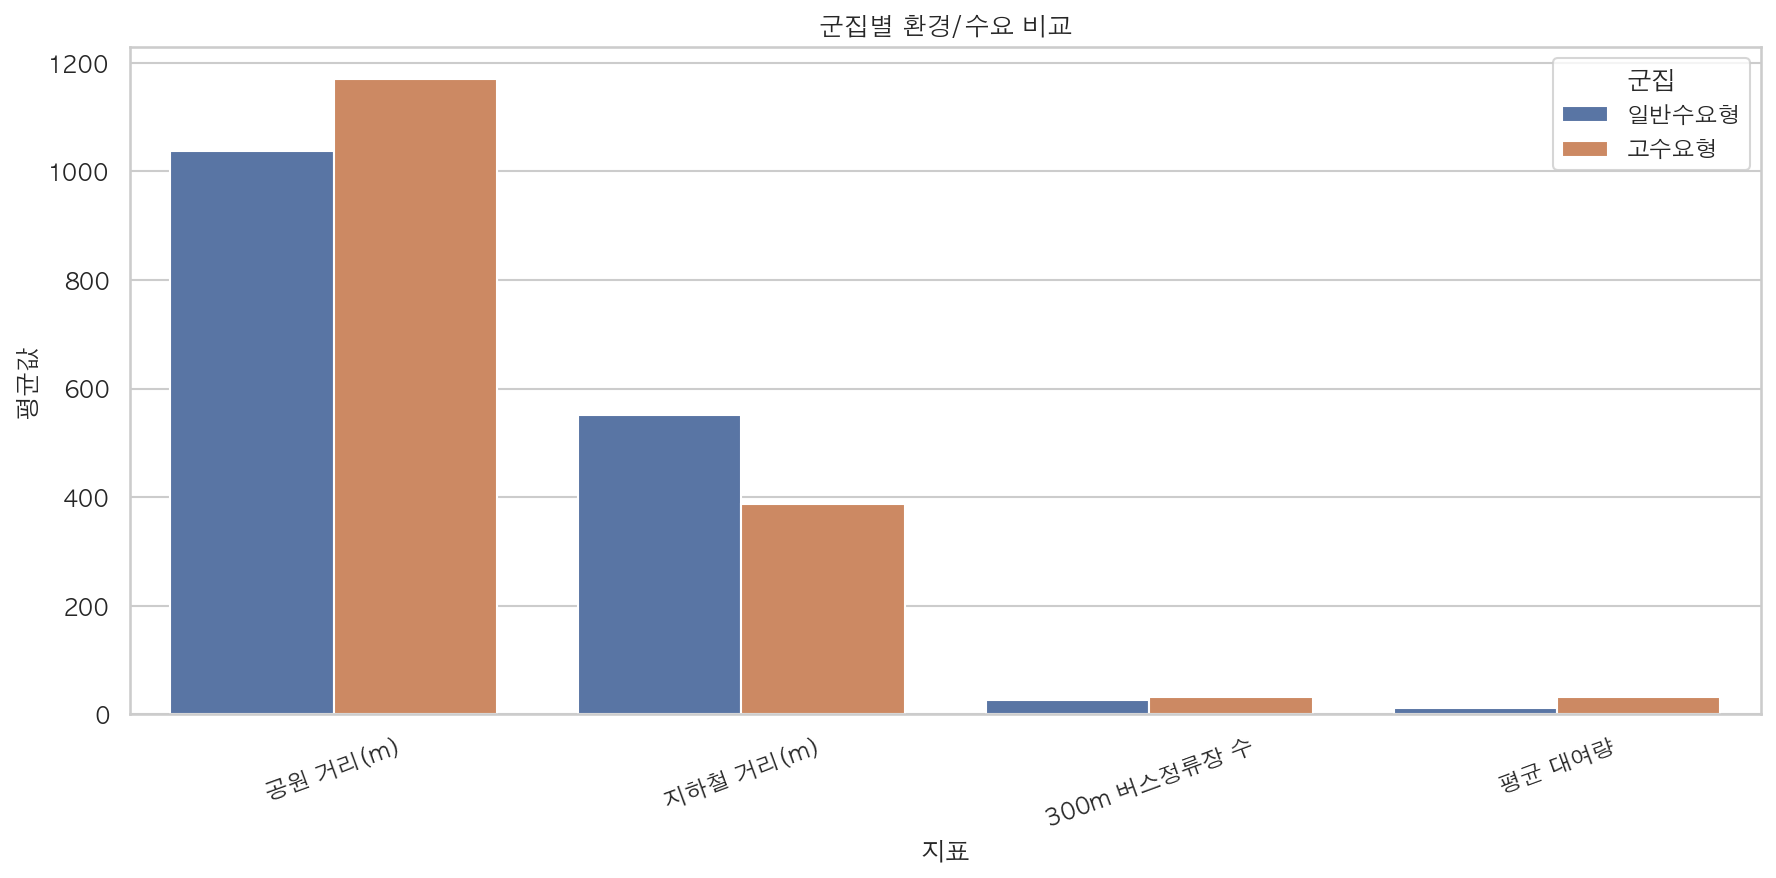

In [4]:
image_path = IMG_DIR / 'ddri_cluster_environment_comparison.png'
print(image_path.exists())
if image_path.exists():
    display(Image(filename=image_path))

## 5. 현재 가능한 해석과 보류한 해석

현재 가능한 해석은 다음과 같다.

- 고수요형 대여소군은 일반수요형보다 지하철 접근성이 더 좋다.
- 고수요형 대여소군은 300m 내 버스정류장 수도 더 많다.
- 따라서 1차 baseline에서는 '교통 접근성이 상대적으로 더 좋은 고수요 대여소군' 해석이 타당하다.

아직 보류하는 해석은 다음과 같다.

- 상업지구형
- 출퇴근형 확정
- 업무지구 중심 수요 단정

이 해석은 POI와 시간대 지표를 더 보강한 뒤 확장하는 것이 맞다.